In [1]:
# Imports
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import scipy.stats as st
import statsmodels.api as sm
import joblib

In [2]:
def mean_impute(a: np.ndarray) -> np.ndarray:
    m = np.nanmean(a)
    out = a.copy()
    out[np.isnan(out)] = m
    return out

def median_impute(a: np.ndarray) -> np.ndarray:
    m = np.nanmedian(a)
    out = a.copy()
    out[np.isnan(out)] = m
    return out

class SimpleLinReg:
    def fit(self, X, y):
        X1 = np.c_[np.ones(len(X)), X.ravel()]
        beta = np.linalg.pinv(X1) @ y
        self.intercept_, self.coef_ = float(beta[0]), np.array([float(beta[1])])
        return self
    def predict(self, X):
        return self.intercept_ + self.coef_[0] * X.ravel()

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def bootstrap_metric(y_true, y_pred, fn, n_boot=500, seed=111, alpha=0.05):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y_true))
    stats = []
    for _ in range(n_boot):
        b = rng.choice(idx, size=len(idx), replace=True)
        stats.append(fn(y_true[b], y_pred[b]))
    lo, hi = np.percentile(stats, [100*alpha/2, 100*(1-alpha/2)])
    return {'mean': float(np.mean(stats)), 'lo': float(lo), 'hi': float(hi)}

def fit_fn(X, y):
    return SimpleLinReg().fit(X, y)
def pred_fn(model, X):
    return model.predict(X)

def fit_ols(x, y):
    """Fits OLS regression and returns model and predicted values."""
    X_const = sm.add_constant(x)
    model = sm.OLS(y, X_const).fit()
    y_pred = model.predict(X_const)
    return model, y_pred

def plot_scatter_with_line(x, y, y_pred, r2, title="Scatter with Regression", xlabel="X", ylabel="Y"):
    """Plots scatter plot and regression line with R^2."""
    plt.figure(figsize=(6,4))
    plt.scatter(x, y, label="Data")
    plt.plot(x, y_pred, color='red', label=f"Regression line\n$R^2={r2:.2f}$")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()

def scatter_with_regression(x, y, title="Scatter with Regression", xlabel="X", ylabel="Y"):
    model, y_pred = fit_ols(x, y)
    r2 = r2_score(y, y_pred)
    plot_scatter_with_line(x, y, y_pred, r2, title, xlabel, ylabel)
    return model
    
def scatter_with_regression_zoom(x, y, title="Scatter with Regression", 
                                 xlabel="X", ylabel="Y", zoom=(0,0)):
    """
    Fit OLS on full data, but optionally zoom in by removing extremes from plotting.
    zoom = (n_x, n_y) removes n_x extreme points from x and n_y from y (top or bottom)
    """
    # If x is a single-column DataFrame, convert to Series
    if isinstance(x, pd.DataFrame) and x.shape[1] == 1:
        x = x.iloc[:,0]
        
    # Fit full model
    model, y_pred = fit_ols(x, y)
    
    # Determine indices to keep
    idx_x = np.arange(len(x))
    idx_y = np.arange(len(y))
    
    if zoom[0] > 0:
        # Remove n_x most extreme x values (top or bottom)
        sorted_x_idx = np.argsort(x)
        idx_x = sorted_x_idx[zoom[0]:-zoom[0]] if zoom[0]*2 < len(x) else sorted_x_idx
    if zoom[1] > 0:
        # Remove n_y most extreme y values (top or bottom)
        sorted_y_idx = np.argsort(y)
        idx_y = sorted_y_idx[zoom[1]:-zoom[1]] if zoom[1]*2 < len(y) else sorted_y_idx
    
    # Intersection of indices to keep
    keep_idx = np.intersect1d(idx_x, idx_y)
    
    # Filter for plotting only
    x_plot = x.iloc[keep_idx] if isinstance(x, pd.Series) else x[keep_idx]
    y_plot = y.iloc[keep_idx] if isinstance(y, pd.Series) else y[keep_idx]
    y_pred_plot = y_pred[keep_idx]
    
    # Plot
    r2 = r2_score(y, y_pred)
    plot_scatter_with_line(x_plot, y_plot, y_pred_plot, r2, title=title, xlabel=xlabel, ylabel=ylabel)
    
    return model

def scatter_two_predictors_side_by_side_with_predictions(X, y, predictor1, predictor2):
    fig, axes = plt.subplots(1, 3, figsize=(18,5))
    
    for i, col in enumerate([predictor1, predictor2]):
        x = X[col]
        X_const = sm.add_constant(X)
        model = sm.OLS(y, X_const).fit()
        y_pred = model.predict(X_const)
        r2 = r2_score(y, y_pred)
        
        # Plot scatter and regression line
        sorted_idx = x.argsort()
        x_sorted = x.iloc[sorted_idx]
        y_pred_sorted = y_pred.iloc[sorted_idx]
        axes[i].scatter(x, y, label="Data", alpha=0.6)
        axes[i].plot(x_sorted, y_pred_sorted, color='red', label=f"Regression line\n$R^2={r2:.2f}$")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Y")
        axes[i].set_title(f"{col} vs Y (full model regression)")
        axes[i].legend()
    
    # Plot predicted vs observed Y
    y_pred_full = sm.OLS(y, sm.add_constant(X)).fit().predict(sm.add_constant(X))
    axes[2].scatter(y, y_pred_full, color='green', alpha=0.6, label="Predicted vs Observed")
    axes[2].plot([y.min(), y.max()], [y.min(), y.max()], color='black', linestyle='--', label='Perfect prediction')
    axes[2].set_xlabel("Observed Y")
    axes[2].set_ylabel("Predicted Y")
    axes[2].set_title("Predicted vs Observed Y")
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()

def plot_residuals_vs_fitted(model, ax=None):
    residuals = model.resid
    fitted = model.fittedvalues
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4))
    ax.scatter(fitted, residuals, alpha=0.6)
    sns.regplot(x=fitted, y=residuals, lowess=True, ax=ax, line_kws={'color':'red'})
    ax.axhline(0, color='black', linestyle='--')
    ax.set_xlabel('Fitted values')
    ax.set_ylabel('Residuals')
    ax.text(0.95,0.05,'Random scatter ~ linearity OK\nFunnel shape ~ heteroscedasticity',
            transform=ax.transAxes, fontsize=9, ha='right', va='bottom', color='blue')
    ax.set_title('Residuals vs Fitted')
    return ax

def plot_scale_location(model, ax=None):
    residuals = model.resid
    fitted = model.fittedvalues
    sqrt_std_resid = np.sqrt(np.abs(residuals / np.std(residuals)))
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4))
    ax.scatter(fitted, sqrt_std_resid, alpha=0.6)
    sns.regplot(x=fitted, y=sqrt_std_resid, lowess=True, ax=ax, line_kws={'color':'red'})
    ax.set_xlabel('Fitted values')
    ax.set_ylabel('Sqrt(|Standardized Residuals|)')
    ax.set_title('Scale-Location')
    ax.text(0.95,0.05,'Horizontal ~ constant variance\nRising/falling ~ heteroscedasticity',
            transform=ax.transAxes, fontsize=9, ha='right', va='bottom', color='blue')
    return ax

def plot_qq(model, ax=None):
    residuals = model.resid
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4))
    sm.qqplot(residuals, line='45', ax=ax)
    ax.set_title('Q-Q Plot')
    ax.text(0.95,0.05,'Points ~45° line → normal\nDeviations → non-normality',
            transform=ax.transAxes, fontsize=9, ha='right', va='bottom', color='blue')
    return ax

def plot_residual_autocorrelation(model, show_acf=True, ax=None):
    residuals = model.resid
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4))
    if show_acf:
        sm.graphics.tsa.plot_acf(residuals, ax=ax)
        ax.set_title('Residual Autocorrelation')
        ax.text(0.95,0.05,'Spikes outside CI → dependence\nOtherwise → independent',
                transform=ax.transAxes, fontsize=9, ha='right', va='bottom', color='blue')
    else:
        ax.scatter(np.arange(len(residuals)), residuals)
        ax.axhline(0, color='red', linestyle='--')
        ax.set_xlabel('Observation')
        ax.set_ylabel('Residuals')
        ax.set_title('Residuals vs Observation')
        ax.text(0.95,0.05,'Random scatter → independent\nPatterns → autocorrelation',
                transform=ax.transAxes, fontsize=9, ha='right', va='bottom', color='blue')
    return ax

def plot_residuals_histogram(model, ax=None):
    residuals = model.resid
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4))
    ax.hist(residuals, bins=20, edgecolor='k', alpha=0.7)
    ax.set_title("Histogram of Residuals")
    ax.set_xlabel("Residual")
    ax.set_ylabel("Frequency")
    ax.text(0.95, 0.95, "Bell-shaped → normal\nSkew/multimodal → non-normal",
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            horizontalalignment='right', color='blue')

def plot_diagnostics_annotated(model, show_acf=True):
    fig, axs = plt.subplots(2, 3, figsize=(18,10))
    
    plot_residuals_vs_fitted(model, ax=axs[0,0])
    plot_scale_location(model, ax=axs[0,1])
    plot_residual_autocorrelation(model, ax=axs[0,2], show_acf=False)  # Residuals vs Observation

    plot_qq(model, ax=axs[1,0])
    plot_residuals_histogram(model, ax=axs[1,1])
    plot_residual_autocorrelation(model, ax=axs[1,2], show_acf=True)  # ACF
    plt.tight_layout()
    plt.show()

In [3]:
# load  data
df = file_path = "../data/raw/engineering_features.csv"
df = pd.read_csv(file_path)
df['ret'] = df['aapl'].pct_change().fillna(0.0)
df['ret_VCNIX'] = df['VCNIX'].pct_change().fillna(0.0)
df['log_ret'] = np.log1p(df['ret'])
df.head()

,Unnamed: 0,date,aapl,VCNIX,aapl_VCNIX_ratio,rolling_aapl_mean,ret,ret_VCNIX,log_ret
0,0,2025-03-28,217.90,20.83,10.460874,NaN,0.000000,0.000000,0.000000
1,1,2025-03-31,222.13,20.83,10.663946,NaN,0.019413,0.000000,0.019227
2,2,2025-04-01,223.19,21.00,10.628095,221.073333,0.004772,0.008161,0.004761
3,3,2025-04-02,223.89,21.16,10.580813,223.070000,0.003136,0.007619,0.003131
4,4,2025-04-03,203.19,20.01,10.154423,216.756667,-0.092456,-0.054348,-0.097013


In [4]:
# TODO: create at least two features
df['lag_1'] = df['ret'].shift(1)
df['roll_mean_5'] = df['ret'].rolling(5).mean().shift(1)
# Add your own:
df['lag_1_VCNIX'] = df['ret_VCNIX'].shift(1)
df['roll_mean_5_VCNIX'] = df['ret_VCNIX'].rolling(5).mean().shift(1)
df['roll_vol_10'] = df['ret'].rolling(10).std().shift(1)
df['lag_5'] = df['ret'].shift(5)
# df['roll_vol_20'] = df['ret'].rolling(20).std().shift(1)
df['y_next_ret'] = df['ret'].shift(-1)
df['y_up'] = (df['y_next_ret']>0).astype(int)
df_feat = df.dropna().copy()
df_feat.head()

,Unnamed: 0,date,aapl,VCNIX,aapl_VCNIX_ratio,rolling_aapl_mean,ret,ret_VCNIX,log_ret,lag_1,roll_mean_5,lag_1_VCNIX,roll_mean_5_VCNIX,roll_vol_10,lag_5,y_next_ret,y_up
10,10,2025-04-11,198.15,20.19,9.814264,195.806667,0.040594,0.019182,0.039792,-0.042394,-0.009709,-0.042070,-0.000067,0.068397,-0.072887,0.022054,1
11,11,2025-04-14,202.52,20.30,9.976355,197.030000,0.022054,0.005448,0.021814,0.040594,0.012987,0.019182,0.015864,0.070324,-0.036734,-0.001876,0
12,12,2025-04-15,202.14,20.34,9.938053,200.936667,-0.001876,0.001970,-0.001878,0.022054,0.024745,0.005448,0.016634,0.070441,-0.049818,-0.038933,0
13,13,2025-04-16,194.27,19.72,9.851420,199.643333,-0.038933,-0.030482,-0.039712,-0.001876,0.034333,0.001970,0.020958,0.070348,0.153288,0.013950,1
14,14,2025-04-17,196.98,19.72,9.988844,197.796667,0.013950,0.000000,0.013853,-0.038933,-0.004111,-0.030482,-0.009190,0.070883,-0.042394,-0.019393,0


In [5]:
# Time-aware split
cut=int(len(df_feat)*0.8)
train, test = df_feat.iloc[:cut], df_feat.iloc[cut:]
features=['lag_1','roll_mean_5']  # extend as you add features
X_tr, X_te = train[features], test[features]
y_tr_reg, y_te_reg = train['y_next_ret'], test['y_next_ret']
y_tr_clf, y_te_clf = train['y_up'], test['y_up']

In [6]:
# Track 1: Forecasting returns
reg = Pipeline([('scaler', StandardScaler()), ('linreg', LinearRegression())])
reg.fit(X_tr, y_tr_reg)
pred = reg.predict(X_te)
mse = mean_squared_error(y_te_reg, pred)
rmse = np.sqrt(mse)
print('RMSE:', rmse)

RMSE: 0.01841310412097214


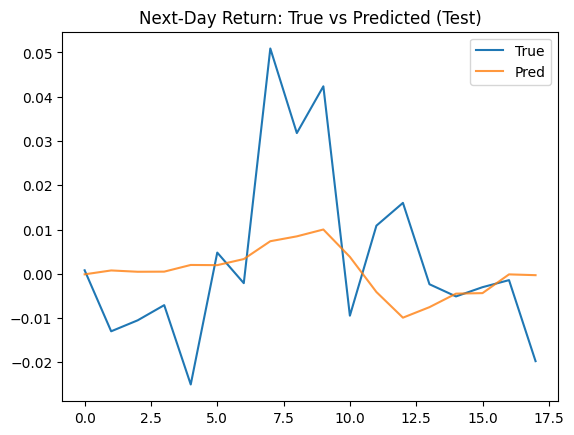

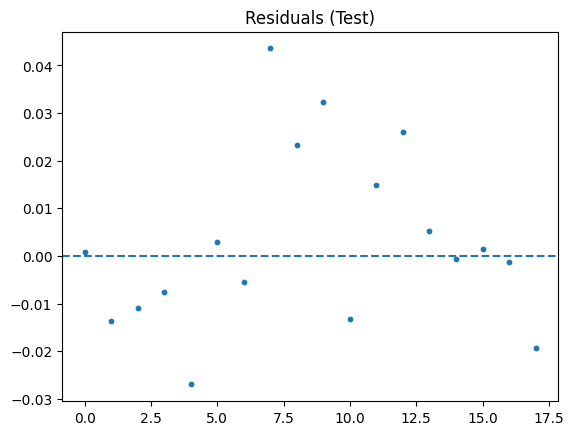

In [7]:
fig, ax = plt.subplots()
y_te_reg.reset_index(drop=True).plot(ax=ax, label='True')
pd.Series(pred).plot(ax=ax, label='Pred', alpha=0.8)
ax.set_title('Next-Day Return: True vs Predicted (Test)')
ax.legend(); plt.show()

resid = y_te_reg.values - pred
fig, ax = plt.subplots()
ax.scatter(range(len(resid)), resid, s=10)
ax.axhline(0, ls='--')
ax.set_title('Residuals (Test)'); plt.show()

              precision    recall  f1-score   support

           0       0.60      0.27      0.38        11
           1       0.38      0.71      0.50         7

    accuracy                           0.44        18
   macro avg       0.49      0.49      0.44        18
weighted avg       0.52      0.44      0.42        18



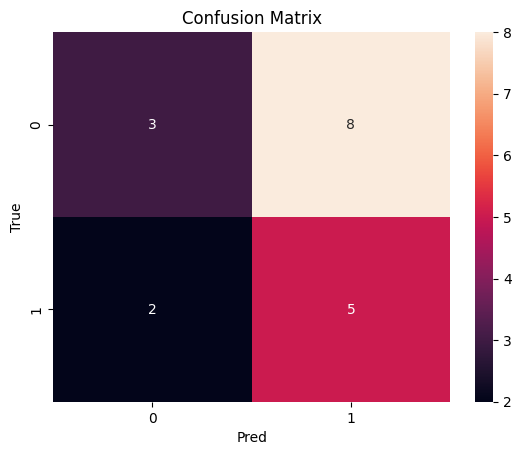

In [8]:
# Track 2: Classification (up/down)
clf = Pipeline([('scaler', StandardScaler()), ('logit', LogisticRegression(max_iter=1000))])
clf.fit(X_tr, y_tr_clf)
predc = clf.predict(X_te)
print(classification_report(y_te_clf, predc))
cm = confusion_matrix(y_te_clf, predc)
sns.heatmap(cm, annot=True, fmt='d'); plt.xlabel('Pred'); plt.ylabel('True');plt.title('Confusion Matrix'); plt.show()

0.0007151128408074913


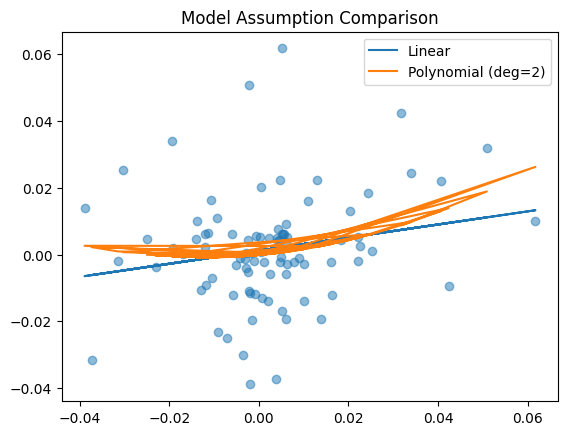

In [19]:
df_mean = df_feat.copy()
print(df['y_next_ret'].mean())
df_mean['y_next_ret'] = df_mean['y_next_ret'].fillna(df['y_next_ret'].mean())

X = df_mean[['ret']]
y = df_mean['y_next_ret']

lin = LinearRegression().fit(X, y)
poly = make_pipeline(PolynomialFeatures(2), LinearRegression()).fit(X, y)

plt.scatter(X, y, alpha=0.5)
plt.plot(X, lin.predict(X), label='Linear')
plt.plot(X, poly.predict(X), label='Polynomial (deg=2)')
plt.legend()
plt.title('Model Assumption Comparison')
plt.show()

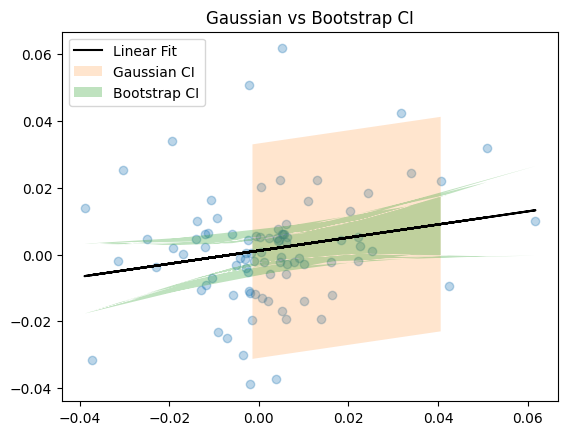

In [20]:
# Predict on full X
y_hat = lin.predict(X)
resid = y - y_hat
sigma = resid.std()

# Gaussian CI (over X, not confidence interval of X itself)
# Builds a 95% confidence interval using ±1.96 × standard deviation.
# Assumes prediction errors are normally distributed.
# This is a quick and theoretical method — doesn't use resampling.
ci_gauss = (y_hat - 1.96*sigma, y_hat + 1.96*sigma)

# Bootstrap CI
boot_preds = []
for _ in range(500):
    #Take a bootstrapped sample of rows from df_mean: a full-size sample with replacement.
    #Introduces variation like a real-world sampling error.   
    # fac=1 => 100% of the original dataset size, (but with replacement)
    sample = df_mean.sample(frac=1, replace=True)
    m = LinearRegression().fit(sample[['ret']], sample['y_next_ret'])
    boot_preds.append(m.predict(X))  # X is 200-length
boot_preds = np.array(boot_preds)

# For each x value, compute the 2.5th and 97.5th percentiles across all 500 predictions.
# This gives a 95% bootstrap confidence interval for each point in X.
ci_boot = (
    np.percentile(boot_preds, 2.5, axis=0),
    np.percentile(boot_preds, 97.5, axis=0)
)

# Plot
plt.scatter(X, y, alpha=0.3)
plt.plot(X['ret'], y_hat, color='black', label='Linear Fit')
plt.fill_between(X['ret'], ci_gauss[0], ci_gauss[1], alpha=0.2, label='Gaussian CI')
plt.fill_between(X['ret'], ci_boot[0],  ci_boot[1],  alpha=0.3, label='Bootstrap CI')
plt.legend()
plt.title('Gaussian vs Bootstrap CI')
plt.show()


In [23]:
# Save the model to disk
os.makedirs('model', exist_ok=True)
joblib.dump(reg, 'model/reg.pkl')

# Test that it works
print("Test prediction:", reg.predict([[0.1, 0.2]]))

Test prediction: [-0.08321734]


C:\Users\kidney\miniconda3\envs\bootcamp_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [28]:
# Save the model to disk
os.makedirs('model', exist_ok=True)
joblib.dump(reg, 'model/lin.pkl')

# Test that it works
print("Test prediction:", lin.predict([[0.1]]))

Test prediction: [0.02077745]


C:\Users\kidney\miniconda3\envs\bootcamp_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
